# Creating the network

In [289]:
import networkx as nx
import pandas as pd
from pathlib import Path
from collections import defaultdict
from preprocess_data import preprocess_posts_and_interactions

## Load Data

In [290]:
data_dir = Path("../data/bluesky")
posts_file = data_dir / "posts_all.jsonl"
interactions_file = data_dir / "interactions_all.jsonl"

posts, interactions = preprocess_posts_and_interactions(str(posts_file), str(interactions_file))
print(f"Loaded {len(posts)} posts and {len(interactions)} interactions")

=== dataset cleaning & dedupe ===
Rows after scanning-spam filter (before dedupe): 8836
Rows after dedupe by uri: 8833

=== URI / interaction summary (unique-URI basis) ===
Total unique clean posts: 8,833
Unique post URIs that appear as interaction targets (in our interact file): 5,264
Unique post URIs with zero interactions: 3,569
Check sum (unique targets + lonely) == total_unique_posts -> 8833 == 8833

=== interactions (filtered to posts we retained) ===
Total interaction rows (original interactions file): 403,598
Interaction rows after filtering to dst_uri in our posts: 368,978
Interaction types (filtered):
like    : 282,677
repost  : 77,338
reply   : 8,963

Distinct users (authors in posts ∪ src_did of filtered interactions): 182,085

=== first 10 cleaned posts (after filtering & dedupe) ===
                                                                                                                           “california require insurers offer home coverage wildfire-prone areas

## Helper Functions

In [291]:
def create_uri_to_author_mapping(posts):
    """Map post URIs to author DIDs"""
    post_to_author = {}
    for _, row in posts.iterrows():
        post_to_author[row['uri']] = row['author_did']
    return post_to_author


def create_did_to_handle_mapping(posts):
    """Map author DIDs to handles"""
    did_to_handle = {}
    for _, row in posts.iterrows():
        if 'author_did' in row and 'author_handle' in row:
            did_to_handle[row['author_did']] = row['author_handle']
    return did_to_handle

## Build Reply-Only Network

In [292]:
def build_replies_only_graph(posts, interactions):
    """Build network using ONLY reply interactions (no likes or reposts)"""
    post_to_author = create_uri_to_author_mapping(posts)
    did_to_handle = create_did_to_handle_mapping(posts)
    
    # Build directed graph
    G_directed = nx.DiGraph()
    interaction_counts = defaultdict(int)
    
    # Filter for replies only, count interactions
    for _, interaction in interactions.iterrows():
        if interaction['edge'] != 'reply':
            continue
            
        src_user = interaction['src_did']
        dst_post = interaction['dst_uri']
        
        if dst_post in post_to_author:
            dst_user = post_to_author[dst_post]
            
            # No self loops
            if src_user != dst_user:
                interaction_counts[(src_user, dst_user)] += 1
    
    # Add edges with weights
    for (src, dst), count in interaction_counts.items():
        G_directed.add_edge(src, dst, weight=count, replies=count)
    
    # Add node attributes
    for node in G_directed.nodes():
        G_directed.nodes[node]['in_degree'] = G_directed.in_degree(node)
        G_directed.nodes[node]['out_degree'] = G_directed.out_degree(node)
        if node in did_to_handle:
            G_directed.nodes[node]['author_handle'] = did_to_handle[node]
    
    # Create undirected version
    G_undirected = G_directed.to_undirected()
    
    # Add node attributes to undirected graph
    for node in G_undirected.nodes():
        G_undirected.nodes[node]['in_degree'] = G_directed.in_degree(node)
        G_undirected.nodes[node]['out_degree'] = G_directed.out_degree(node)
        G_undirected.nodes[node]['degree'] = G_undirected.degree(node)
        if node in did_to_handle:
            G_undirected.nodes[node]['author_handle'] = did_to_handle[node]
    
    print(f"Directed: {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
    print(f"Undirected: {G_undirected.number_of_nodes()} nodes, {G_undirected.number_of_edges()} edges")
    
    return G_directed, G_undirected

## Create Graphs

In [293]:
G_directed, G_undirected = build_replies_only_graph(posts, interactions)

Directed: 8094 nodes, 7801 edges
Undirected: 8094 nodes, 7801 edges


## Save Graphs

In [294]:
nx.write_gml(G_directed, data_dir / "user_interaction_graph_directed.gml")
nx.write_gml(G_undirected, data_dir / "user_interaction_graph_undirected.gml")
print("Graphs saved")

Graphs saved


## Network Statistics

In [295]:
import numpy as np

G = G_undirected # we use the undirected from here on

### Basic Properties

In [296]:
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Density: {nx.density(G):.6f}")

Nodes: 8,094
Edges: 7,801
Density: 0.000238


### Degree Statistics

In [297]:
degrees = [d for n, d in G.degree()]

print(f"Mean degree: {np.mean(degrees):.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Std degree: {np.std(degrees):.2f}")
print(f"Max degree: {np.max(degrees)}")
print(f"Min degree: {np.min(degrees)}")

Mean degree: 1.93
Median degree: 1.00
Std degree: 13.84
Max degree: 791
Min degree: 1


### Connectivity

In [298]:
components = list(nx.connected_components(G))
largest_cc = max(components, key=len)

print(f"Number of components: {len(components)}")
print(f"Largest component size: {len(largest_cc):,} ({len(largest_cc)/G.number_of_nodes():.2%})")

Number of components: 697
Largest component size: 6,104 (75.41%)


### Assortativity

In [299]:
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity: {assortativity:.4f}")

Degree assortativity: -0.2315


### Top Nodes by Degree Centrality

In [300]:
degree_centrality = nx.degree_centrality(G)
top_degree_cent = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by degree centrality:")
for node, score in top_degree_cent:
    handle = G.nodes[node].get('author_handle', 'unknown')
    print(f"  {handle}: {score:.4f}")

Top 5 nodes by degree centrality:
  artcandee.bsky.social: 0.0977
  patriottakes.bsky.social: 0.0696
  governor.ca.gov: 0.0586
  npr.org: 0.0236
  aaronparnas.bsky.social: 0.0217


### Top Nodes by Betweenness Centrality

In [301]:
betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by betweenness centrality:")
for node, score in top_betweenness:
    handle = G.nodes[node].get('author_handle', 'unknown')
    print(f"  {handle}: {score:.4f}")

Top 5 nodes by betweenness centrality:
  artcandee.bsky.social: 0.2687
  governor.ca.gov: 0.1417
  patriottakes.bsky.social: 0.1384
  npr.org: 0.0466
  juddlegum.bsky.social: 0.0417


## Louvain Community Detection

In [302]:
import community as community_louvain

### Run Louvain Algorithm

In [303]:
# Extract gcc
G_gcc = G.subgraph(largest_cc).copy()
coverage = (G_gcc.number_of_nodes() / G.number_of_nodes()) * 100
print(f"Running Louvain on GCC: {G_gcc.number_of_nodes()} nodes, {G_gcc.number_of_edges()} edges ({coverage:.1f}% of network)")

communities = community_louvain.best_partition(G_gcc, weight='weight', random_state=42)

# Add community assignments to nodes
for node, comm_id in communities.items():
    G_gcc.nodes[node]['community'] = comm_id

print(f"Found {len(set(communities.values()))} communities")

Running Louvain on GCC: 6104 nodes, 6507 edges (75.4% of network)
Found 57 communities


### Community Statistics

In [304]:
from collections import Counter

# Count community sizes
comm_sizes = Counter(communities.values())

print(f"Number of communities: {len(comm_sizes)}")
print(f"Mean community size: {np.mean(list(comm_sizes.values())):.2f}")
print(f"Median community size: {np.median(list(comm_sizes.values())):.2f}")
print(f"Largest community: {max(comm_sizes.values())} nodes")
print(f"Smallest community: {min(comm_sizes.values())} node(s)")

Number of communities: 57
Mean community size: 107.09
Median community size: 79.00
Largest community: 694 nodes
Smallest community: 7 node(s)


### Modularity

In [305]:
from networkx.algorithms.community import modularity as nx_modularity

comm_dict = defaultdict(set)
for node, comm_id in communities.items():
    comm_dict[comm_id].add(node)
communities_list = list(comm_dict.values())

modularity = nx_modularity(G_gcc, communities_list)
print(f"Modularity: {modularity:.4f}")

Modularity: 0.8902


### Top Communities by Size

In [306]:
top_communities = comm_sizes.most_common(10)

print("Top 10 communities by size:")
for comm_id, size in top_communities:
    print(f"Community {comm_id}: {size} nodes")

Top 10 communities by size:
Community 4: 694 nodes
Community 11: 530 nodes
Community 7: 436 nodes
Community 8: 208 nodes
Community 9: 180 nodes
Community 12: 179 nodes
Community 24: 178 nodes
Community 19: 175 nodes
Community 20: 170 nodes
Community 37: 165 nodes


### Save Communities

In [307]:
import json

# Save community assignments
with open(data_dir / "louvain_communities.json", 'w') as f:
    json.dump(communities, f, indent=2)

print("Communities saved")

Communities saved


## Sentiment by Community

In [308]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

### Compute Sentiment Scores

In [309]:
analyzer = SentimentIntensityAnalyzer()
posts['sentiment'] = posts['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
print(f"Computed sentiment for {len(posts)} posts")

Computed sentiment for 8833 posts


### Map Posts to Communities

In [310]:
# Map author DIDs to communities
node_community = {}
for node in G_gcc.nodes():
    comm_id = G_gcc.nodes[node].get('community')
    if comm_id is not None:
        node_community[node] = comm_id

posts['community'] = posts['author_did'].map(node_community)
community_posts = posts.dropna(subset=['community'])
community_posts['community'] = community_posts['community'].astype(int)

print(f"Mapped {len(community_posts)} posts to communities")

Mapped 1340 posts to communities


### Aggregate Sentiment by Community

In [311]:
# Aggregate sentiment by community
sentiment_stats = community_posts.groupby('community')['sentiment'].agg(['mean', 'std', 'count'])

# Filter to communities with at least 10 posts for better accuracy
min_posts = 10
sentiment_stats = sentiment_stats[sentiment_stats['count'] >= min_posts]

# Calculate standard error of mean
sentiment_stats['sem'] = sentiment_stats['std'] / np.sqrt(sentiment_stats['count'])

print(f"Communities with at least {min_posts} posts: {len(sentiment_stats)}")

Communities with at least 10 posts: 35


### Add Community Metadata

In [312]:
# Add node counts and leaders
comm_nodes = defaultdict(list)
for node in G_gcc.nodes():
    comm_id = G_gcc.nodes[node].get('community')
    if comm_id is not None:
        degree = G_gcc.degree(node)
        handle = G_gcc.nodes[node].get('author_handle', 'Unknown')
        comm_nodes[comm_id].append((degree, handle))

# Add to stats
leaders = []
node_counts = []
for comm_id in sentiment_stats.index:
    nodes = comm_nodes.get(comm_id, [])
    node_counts.append(len(nodes))
    if nodes:
        _, handle = max(nodes, key=lambda x: x[0])
        leaders.append(handle)
    else:
        leaders.append("Unknown")

sentiment_stats['leader'] = leaders
sentiment_stats['node_count'] = node_counts

### Top Communities by Size with Sentiment

In [313]:
print("Top 10 communities by node count:")
top_10 = sentiment_stats.sort_values('node_count', ascending=False).head(10)
print(top_10[['node_count', 'count', 'mean', 'sem', 'leader']])

Top 10 communities by node count:
           node_count  count      mean       sem                    leader
community                                                                 
4                 694     50 -0.025074  0.083936     artcandee.bsky.social
11                530     55 -0.121467  0.069597  patriottakes.bsky.social
7                 436     53 -0.062651  0.070003           governor.ca.gov
8                 208     28 -0.182304  0.090938                   npr.org
9                 180     23 -0.112861  0.088650    georebekah.bsky.social
12                179     27 -0.331344  0.098799            astrokatie.com
24                178     12 -0.165867  0.142999     juddlegum.bsky.social
19                175     14 -0.291921  0.147568       governorwalz.mn.gov
20                170     15 -0.002207  0.192687      droddman.bsky.social
37                165     22 -0.068273  0.088697   aaronparnas.bsky.social


## Community Visualization (cuGraph GPU)

In [324]:
import cugraph
import cudf
import matplotlib.pyplot as plt

### Prepare Graph for GPU Layout

In [325]:
# Filter to top communities for visualization
top_n = 10
comm_counts = {}
for n in G_gcc.nodes():
    c = G_gcc.nodes[n].get('community', 0)
    comm_counts[c] = comm_counts.get(c, 0) + 1

sorted_comms = sorted(comm_counts.items(), key=lambda x: x[1], reverse=True)
top_comms = {c for c, _ in sorted_comms[:top_n]}

G_viz = G_gcc.subgraph([n for n in G_gcc.nodes() if G_gcc.nodes[n].get('community', 0) in top_comms]).copy()
print(f"Visualizing top {top_n} communities: {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges")

Visualizing top 10 communities: 2915 nodes, 3025 edges


### Compute Force Atlas 2 Layout (GPU)

In [326]:
# Map string node IDs to integers
node_list = list(G_viz.nodes())
node_to_int = {node: i for i, node in enumerate(node_list)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Build edge DataFrame
edge_data = [(node_to_int[u], node_to_int[v], float(d.get('weight', 1.0))) 
             for u, v, d in G_viz.edges(data=True)]
edge_df = cudf.DataFrame(edge_data, columns=['src', 'dst', 'weight'])

cu_G = cugraph.Graph()
cu_G.from_cudf_edgelist(edge_df, source='src', destination='dst', edge_attr='weight')

pos_df = cugraph.layout.force_atlas2(
    cu_G,
    max_iter=5000,
    outbound_attraction_distribution=False,
    lin_log_mode=True,
    edge_weight_influence=3.0,
    jitter_tolerance=1.0,
    barnes_hut_optimize=True,
    barnes_hut_theta=0.8,
    scaling_ratio=10.0,
    gravity=5.0
)

# Convert to CPU
pos_df_host = pos_df.to_pandas()
pos_map = {row.vertex: (float(row.x), float(row.y)) 
           for row in pos_df_host.itertuples(index=False)}
positions = {int_to_node[idx]: pos_map[idx] for idx in int_to_node if idx in pos_map}

print("Layout computed")

Layout computed


### Visualize Communities

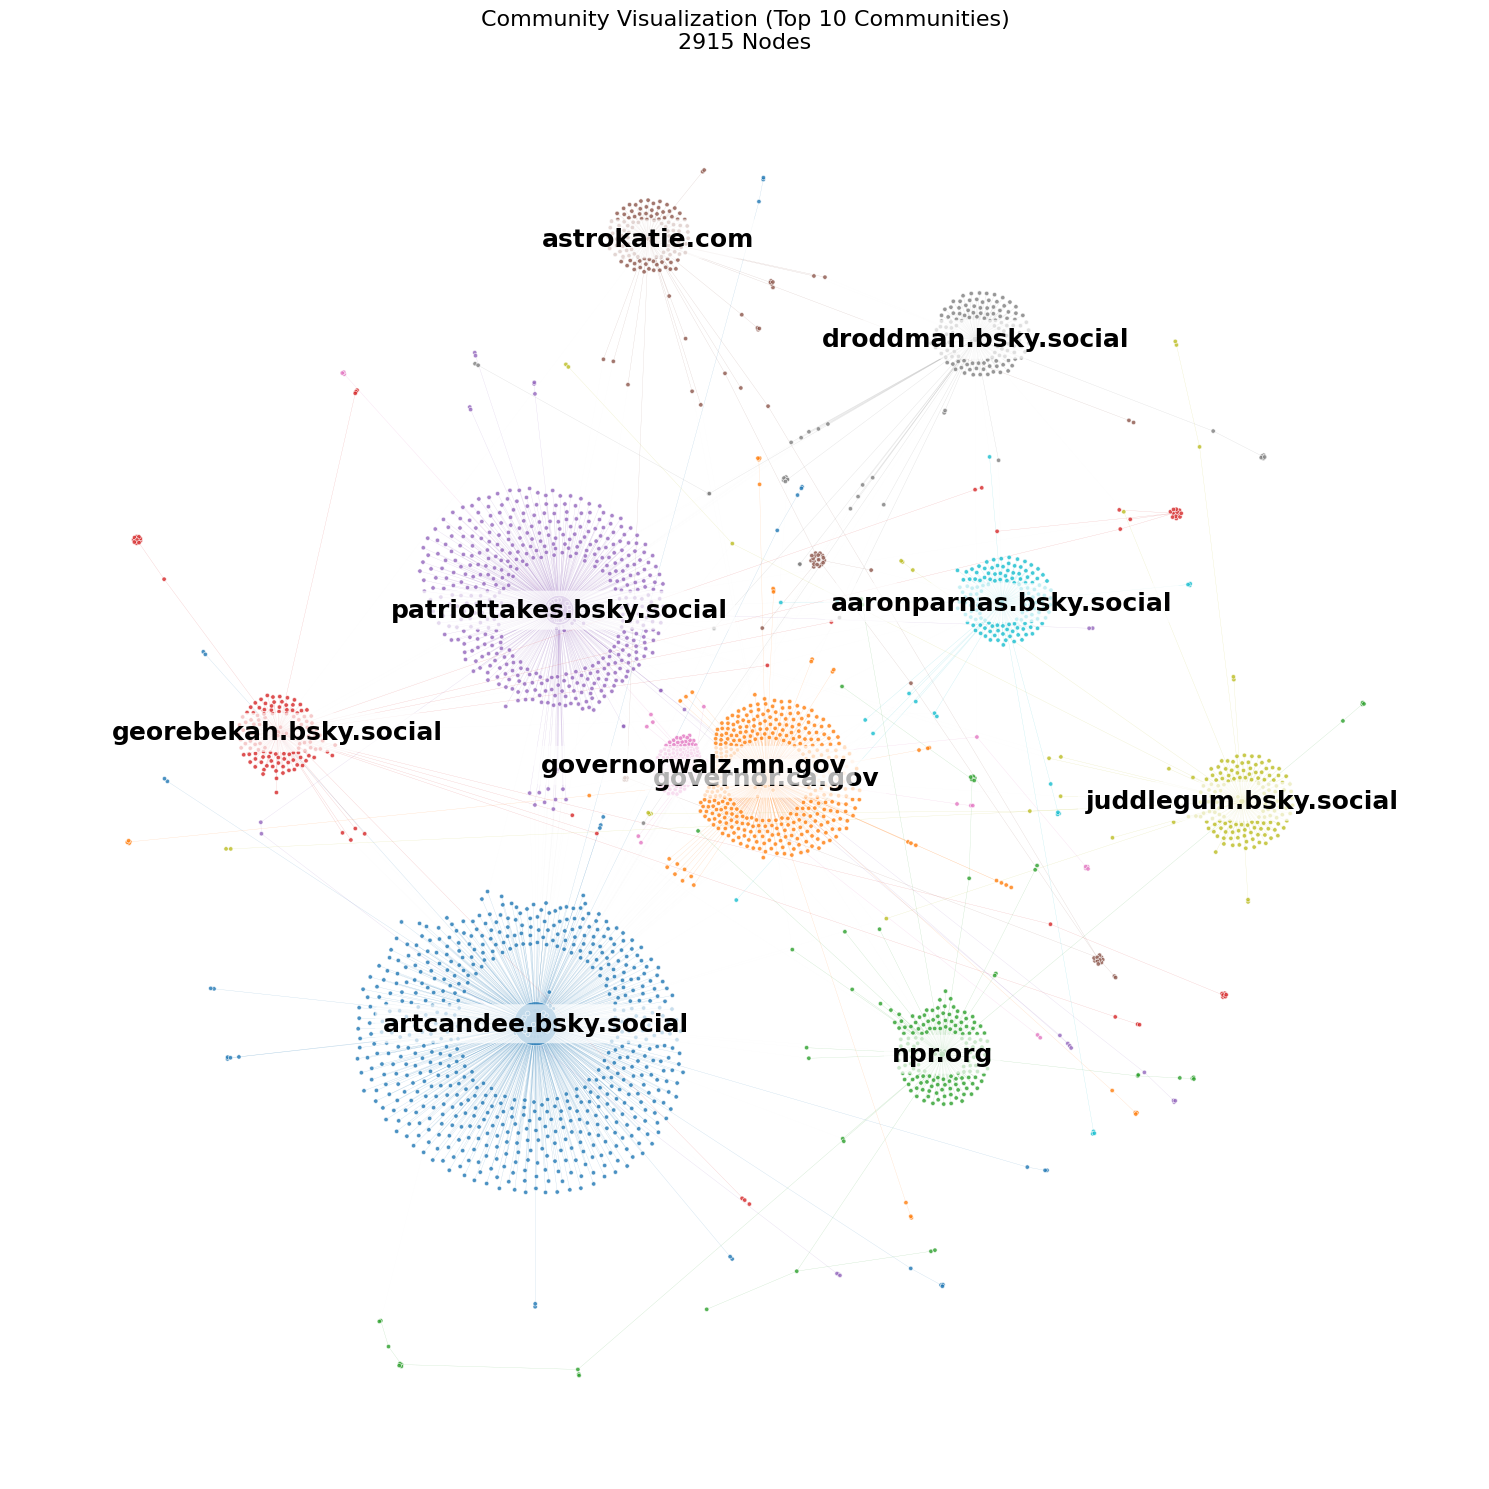

In [327]:
nodes_iter = list(G_viz.nodes())

# Get communities and node sizes
communities_viz = [int(G_viz.nodes[n].get('community', 0)) for n in nodes_iter]
node_interactions = dict(G_viz.degree(weight='weight'))

# Node sizes based on interactions
sizes_raw = np.array([node_interactions.get(n, 1) for n in nodes_iter])
norm = (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min() + 1e-9)
sizes_final = (norm ** 3 * 990 + 10)

# Color mapping
unique_comm_ids = sorted(set(communities_viz))
comm_to_idx = {comm_id: idx for idx, comm_id in enumerate(unique_comm_ids)}
community_indices = [comm_to_idx[c] for c in communities_viz]
cmap = plt.colormaps.get_cmap('tab10').resampled(len(unique_comm_ids))

# Find top node in each community for labels
top_nodes = {}
for n in nodes_iter:
    c = G_viz.nodes[n].get('community', 0)
    score = node_interactions.get(n, 0)
    if c not in top_nodes or score > top_nodes[c][1]:
        top_nodes[c] = (n, score)

labels_to_draw = {}
for c, (n, _) in top_nodes.items():
    handle = G_viz.nodes[n].get('author_handle', n)
    labels_to_draw[n] = handle

# Plot
plt.figure(figsize=(15, 15))

# Separate edges by community
valid_edges = [(u, v) for u, v in G_viz.edges() if u in positions and v in positions]
edge_weights = np.array([G_viz[u][v].get('weight', 1.0) for u, v in valid_edges])
if len(edge_weights) > 0 and edge_weights.max() > edge_weights.min():
    weight_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min())
    edge_widths = weight_norm * 2.8 + 0.2
else:
    edge_widths = np.ones(len(valid_edges))

# Separate intra-community and inter-community edges
intra_comm_edges = {}
inter_comm_edges = []
inter_comm_widths = []

for idx, (u, v) in enumerate(valid_edges):
    comm_u = G_viz.nodes[u].get('community', 0)
    comm_v = G_viz.nodes[v].get('community', 0)
    
    if comm_u == comm_v:
        # Intra-community edge
        if comm_u not in intra_comm_edges:
            intra_comm_edges[comm_u] = []
        intra_comm_edges[comm_u].append((u, v, edge_widths[idx]))
    else:
        # Inter-community edge
        inter_comm_edges.append((u, v))
        inter_comm_widths.append(edge_widths[idx] * 0.5)

# Draw inter-community edges first (gray, faint)
if inter_comm_edges:
    nx.draw_networkx_edges(G_viz, positions, edgelist=inter_comm_edges,
                          alpha=0.05, edge_color='gray', arrows=False, width=inter_comm_widths)

# Draw intra-community edges with community colors
for comm_id, edge_data in intra_comm_edges.items():
    color_idx = comm_to_idx[comm_id]
    color = cmap(color_idx)
    edges = [(u, v) for u, v, _ in edge_data]
    widths = [w for _, _, w in edge_data]
    nx.draw_networkx_edges(G_viz, positions, edgelist=edges,
                          alpha=0.3, edge_color=color, arrows=False, width=widths)

# Draw nodes
nx.draw_networkx_nodes(G_viz, positions, node_size=sizes_final.tolist(),
                      node_color=community_indices, cmap=cmap, alpha=0.8,
                      linewidths=0.5, edgecolors='white')

# Draw labels
nx.draw_networkx_labels(G_viz, positions, labels_to_draw,
                       font_size=18, font_color='black', font_weight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))

plt.title(f'Community Visualization (Top {top_n} Communities)\n{G_viz.number_of_nodes()} Nodes', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()